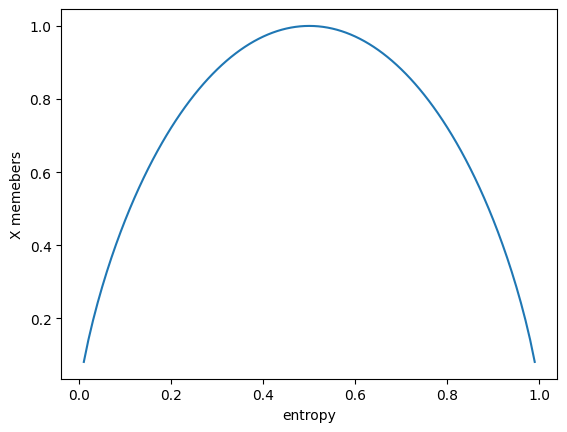

In [1]:
import matplotlib.pyplot as plt
import numpy as np
def entropy(p):
    return -p  * np.log2(p) - (1-p) * np.log2((1-p))
x = np.arange(0.0,1.0,0.01)

ent = [entropy(p) if  p!=0 else None for p in x]

plt.xlabel("entropy")
plt.ylabel("X memebers")

plt.plot(x,ent)
plt.show()

Text(0, 0.5, 'Impurity Idx')

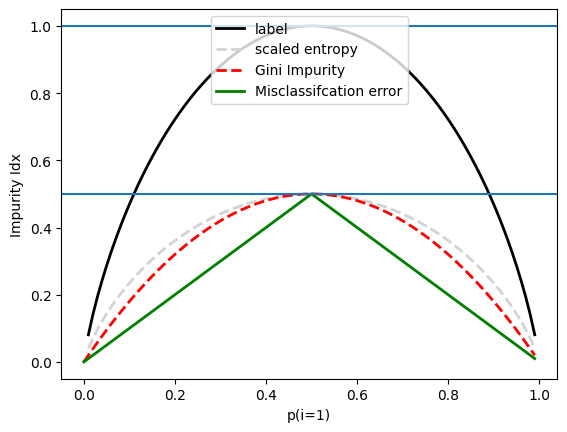

In [2]:
def gini(p):
    return  p*(1-p) + (1-p)*(1-(1-p))
def error(p):     #Classification error
    return 1- np.max([p,1-p])

x = np.arange(0.0,1.0,0.01)

ent = [entropy(p) if p != 0 else None for p in x]

sc_ent = [e * 0.5 if e else None for e in ent]

err = [error(i) for i in x]

fig = plt.figure()
ax = plt.subplot(111)

for i, lab, ls, c in zip([ent,sc_ent, gini(x),err],["label","scaled entropy", "Gini Impurity", "Misclassifcation error"],[ "-","--","--","-"], ["black","lightgray","red","green","cyan"]):
    line = ax.plot(x,i, label = lab, linestyle = ls, lw = 2, color = c)

ax.legend(loc = "upper center")
ax.axhline(y =0.5)
ax.axhline(y = 1.0)
plt.xlabel("p(i=1)")
plt.ylabel("Impurity Idx")



# Lets Try Visualizing

In [7]:
import numpy as np
from sklearn import datasets

iris = datasets.load_iris()

X = iris.data[:,[2,3]] #for any row use column 3 and 4

y = iris.target

print(np.unique(y)) # The class names Iris-setosa, Iris-versicolor, and Iris-virginica are stored as integer for technical and memory issues



[0 1 2]


In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X,y,test_size= 0.3, random_state= 42, stratify=y) #stratify make sure all data are proportional using Y

print(np.bincount(y_test))# Counting the number of the Y tests

[15 15 15]


In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def plot_Decision(x,y,classifire, resolution = 0.02):
    markers = "o","*","s","d"
    colors = ("blue","green","red","yellow")
    cmap = ListedColormap(colors[:len(np.unique(y))]) # Creaye a unique color for each value Y



    x_min, x_max =(x[:,0].min()-1,x[:,0].max() + 1) #Padding
    x1_min,x2_max = (x[:,1].min() - 1, x[:1].max() + 1)    
    xx1,xx2 = np.meshgrid(np.arange(x_min,x_max,resolution), np.arange(x1_min,x2_max,resolution)) #Np.arreange(start, stop,increment)
    #meshgrid converts from 1D to ND(2)

    lab = classifire.predict(np.array([xx1.ravel(),  xx2.ravel()]).T) # ravel flatens the values , T is transpose
    lab = lab.reshape(xx1.shape) # xx1 have same shape as xx2

    plt.contourf(xx1,xx2,lab, alpha = 0.4, cmap = cmap)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())

    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = x[y == cl, 0], y = x[y == cl,1 ], color = colors[idx], marker = markers[idx],edgecolor = "black")


C:\Users\Aron\AppData\Local\Temp\ipykernel_21884\2108309743.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'upper left')


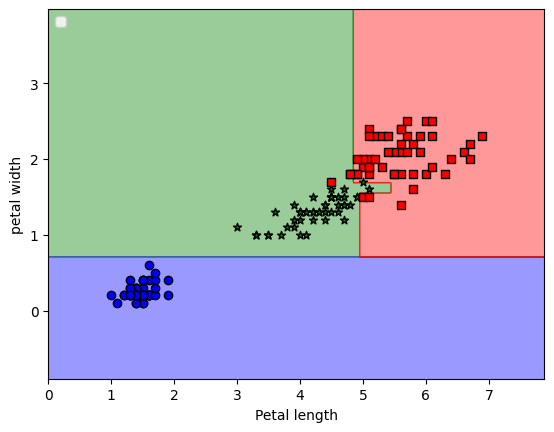

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_mod = DecisionTreeClassifier(criterion = 'gini', max_depth= 4, random_state= 21)
tree = tree_mod.fit(X_train,y_train)

x_combined =  np.vstack((X_train,X_test))
y_combined = np.hstack((y_train,y_test))

plot_Decision(x_combined,y_combined,classifire = tree_mod)
plt.xlabel("Petal length")
plt.ylabel("petal width")

plt.legend(loc = 'upper left')
plt.show()




[Text(0.3181818181818182, 0.9, 'sepal_width <= 0.7\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]'),
 Text(0.22727272727272727, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.2727272727272727, 0.8, 'True  '),
 Text(0.4090909090909091, 0.7, 'sepal_width <= 1.55\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]'),
 Text(0.36363636363636365, 0.8, '  False'),
 Text(0.18181818181818182, 0.5, 'sepal length <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.09090909090909091, 0.3, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.2727272727272727, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6363636363636364, 0.5, 'sepal_width <= 1.7\ngini = 0.105\nsamples = 36\nvalue = [0, 2, 34]'),
 Text(0.45454545454545453, 0.3, 'sepal length <= 5.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.36363636363636365, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.5454545454545454, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 T

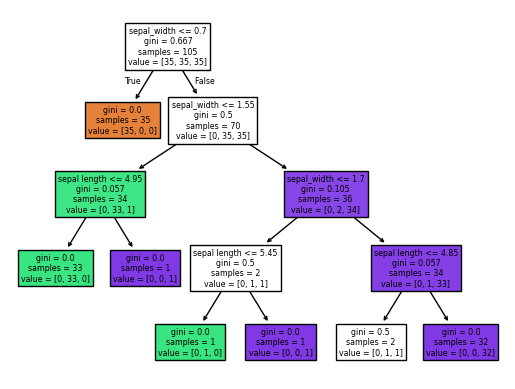

In [17]:
from sklearn import tree

feature_Name = ["sepal length","sepal_width", 'petal legthn','petal width']

tree.plot_tree(tree_mod, feature_names= feature_Name, filled = True) # Filled is for colors